Esplorazione dataset


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("mental_health_dataset.csv")

df.head()
df.tail()

,Patient_ID,Age,Gender,Sleep_Hours_Per_Day,Work_Hours_Per_Week,Exercise_Frequency_Per_Week,Mood_Score (0-100),Anxiety_Score (0-100),Depression_Score (0-100),Stress_Score (0-100),...,Social_Interaction (1-10),Concentration (1-10),Appetite (1-10),Life_Satisfaction (0-100),Therapy_Sessions_Per_Month,Medication,Family_History,Hallucinations,Manic_Episodes_Per_Year,Mental_Health_Condition
1195,P1196,23,Female,7.5,45,4,76,17,7,5,...,8,7,8,75,0,0,1,0,0,Normal
1196,P1197,58,Male,7.4,13,4,88,5,10,19,...,9,8,7,73,1,0,1,0,0,Normal
1197,P1198,63,Female,7.8,46,6,89,20,7,6,...,6,7,7,90,1,0,0,0,0,Normal
1198,P1199,61,Female,4.7,7,0,28,78,50,67,...,3,2,5,24,6,1,1,1,0,Schizophrenia
1199,P1200,48,Female,5.7,60,0,47,93,52,90,...,4,2,4,31,5,0,0,0,0,Anxiety


info e describe

In [ ]:
df.info()

In [ ]:
df.describe()

Controllo duplicati null ecc

In [ ]:
df.duplicated().sum()
df.isna().sum()

droppiamo valori non numerici


In [ ]:
df2 = df.drop(["Patient_ID","Gender","Mental_Health_Condition"], axis = 1)
df2.corr()

Correlazioni

In [ ]:
corr = df2.corr()

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)

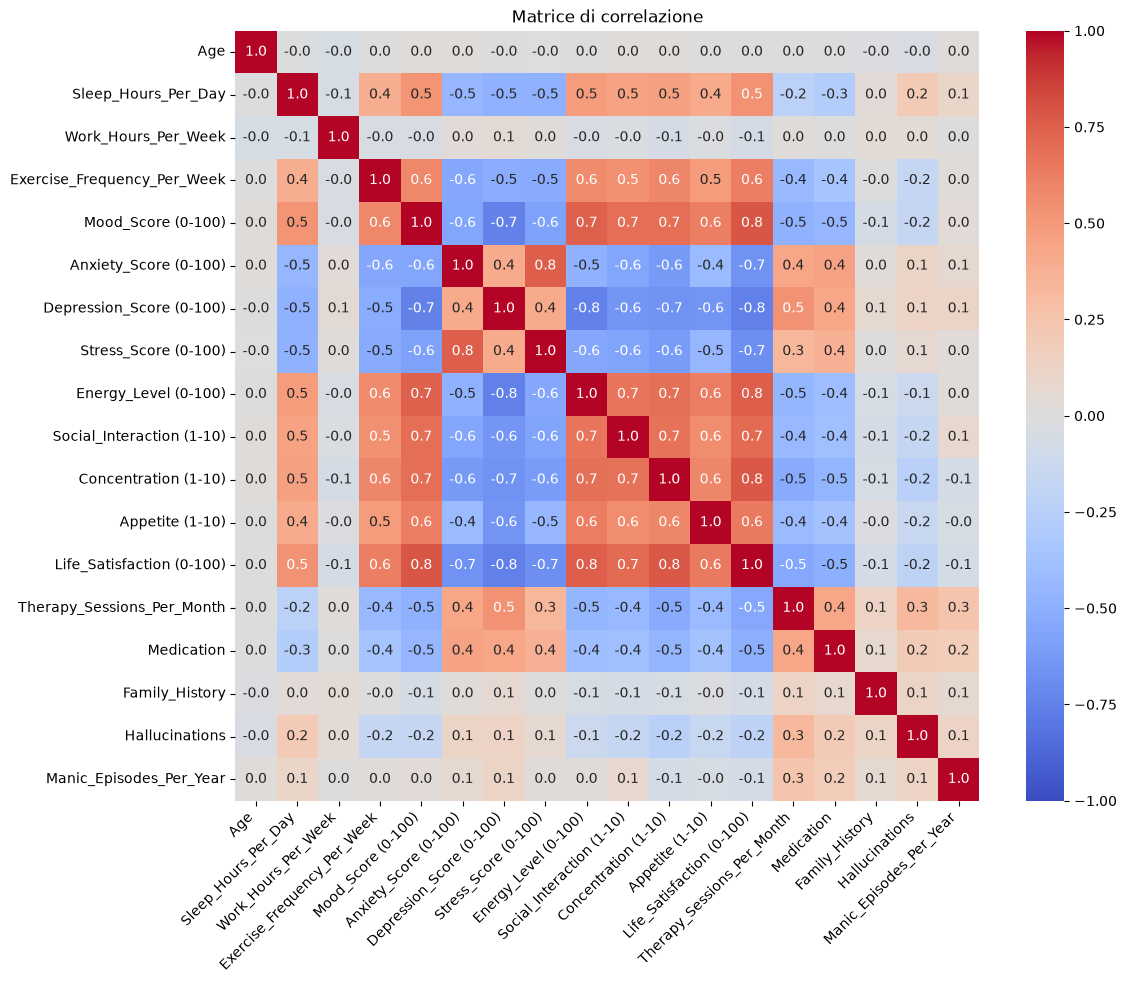

In [69]:

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,        
    fmt=".1f",           
    cmap="coolwarm",     
    vmin=-1,
    vmax=1,
  
)

plt.title("Matrice di correlazione")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)



plt.show()

grafico mood score per genere e mental condition

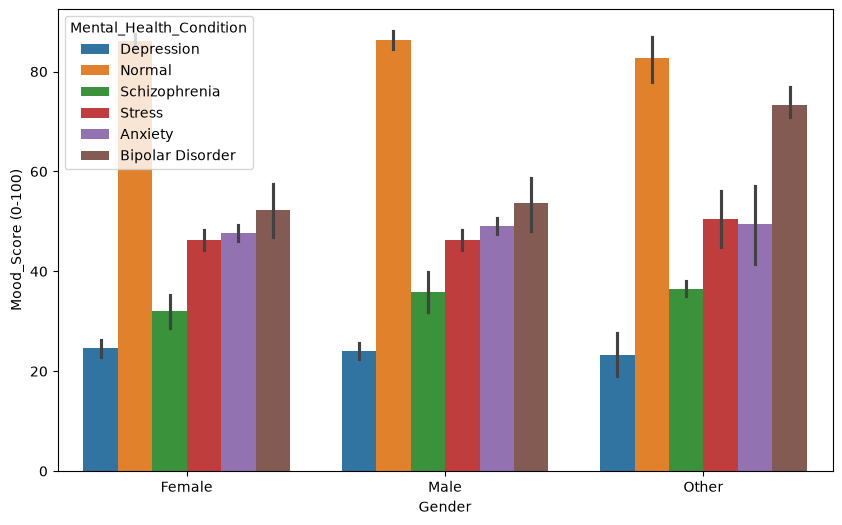

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x="Gender", y="Mood_Score (0-100)", hue="Mental_Health_Condition", data=df)
plt.show()

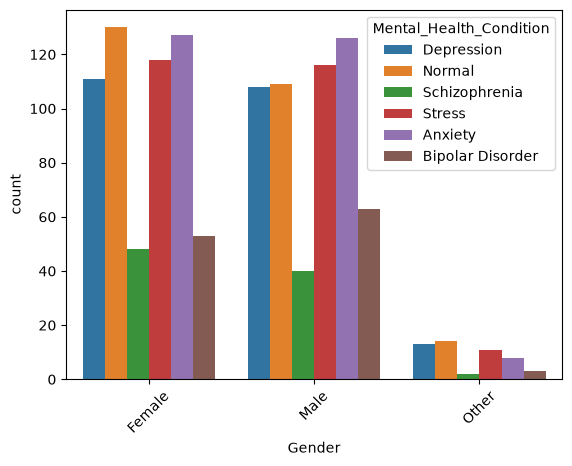

In [38]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Mental_Health_Condition"
)
plt.xticks(rotation=45)
plt.show()

distrubuzione delle condizioni mentali

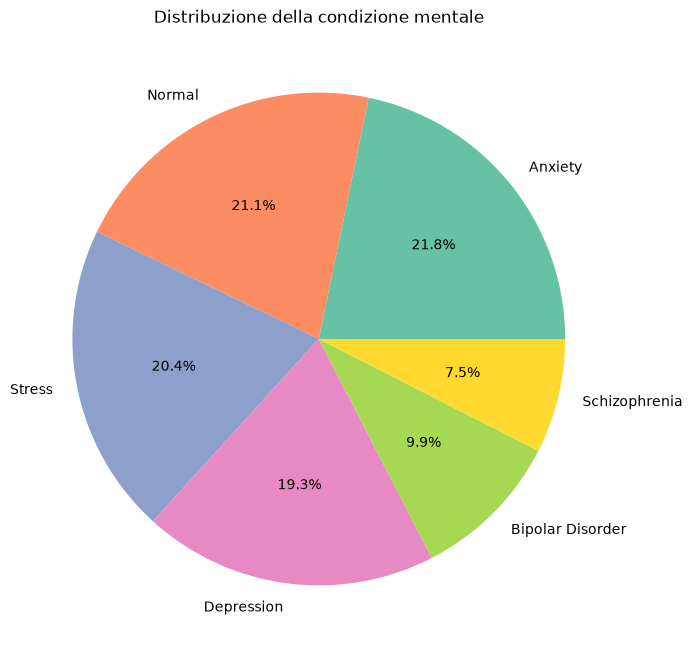

In [58]:
conteggi = df["Mental_Health_Condition"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    conteggi,
    labels=conteggi.index,
    autopct="%1.1f%%",
    colors=plt.cm.Set2.colors
)

plt.title("Distribuzione della condizione mentale") 
plt.show()

In [34]:
counts = df['Gender'].value_counts()
print("SOMMA DEI GENDER", counts)

somma2 = df["Patient_ID"].count()
print("SOMMA DEI RECORD", somma2)

SOMMA DEI GENDER Gender
Female    587
Male      562
Other      51
Name: count, dtype: int64
SOMMA DEI RECORD 1200


grafico distr eta

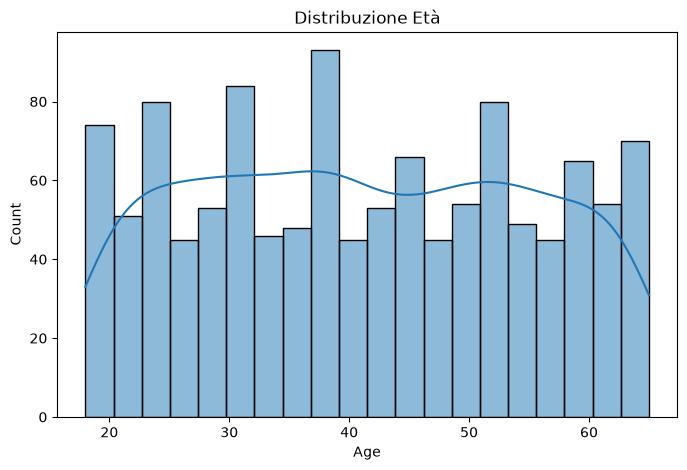

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribuzione Età")
plt.show()

creare colonna label per eta

In [75]:
rangeEta = [17, 30, 50, 120]

df["Age_label"] = pd.cut(
    df["Age"],
    bins=rangeEta,
    labels=["giovane", "adulto", "anziano"]
)

df

,Patient_ID,Age,Gender,Sleep_Hours_Per_Day,Work_Hours_Per_Week,Exercise_Frequency_Per_Week,Mood_Score (0-100),Anxiety_Score (0-100),Depression_Score (0-100),Stress_Score (0-100),...,Concentration (1-10),Appetite (1-10),Life_Satisfaction (0-100),Therapy_Sessions_Per_Month,Medication,Family_History,Hallucinations,Manic_Episodes_Per_Year,Mental_Health_Condition,Age_label
0,P0001,29,Female,5.0,48,1,38,56,77,70,...,3,4,29,5,1,1,0,0,Depression,giovane
1,P0002,24,Male,8.0,41,3,84,4,9,19,...,10,7,94,1,0,0,0,0,Normal,giovane
2,P0003,46,Male,8.3,57,0,27,46,49,68,...,4,4,36,4,1,1,1,0,Schizophrenia,adulto
3,P0004,28,Male,4.1,38,4,53,56,26,80,...,6,6,34,1,0,0,0,0,Stress,giovane
4,P0005,50,Male,5.2,15,3,33,94,35,82,...,6,4,27,5,1,0,0,0,Anxiety,adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,P1196,23,Female,7.5,45,4,76,17,7,5,...,7,8,75,0,0,1,0,0,Normal,giovane
1196,P1197,58,Male,7.4,13,4,88,5,10,19,...,8,7,73,1,0,1,0,0,Normal,anziano
1197,P1198,63,Female,7.8,46,6,89,20,7,6,...,7,7,90,1,0,0,0,0,Normal,anziano
1198,P1199,61,Female,4.7,7,0,28,78,50,67,...,2,5,24,6,1,1,1,0,Schizophrenia,anziano


In [76]:
df[df["Age"] == 18]

,Patient_ID,Age,Gender,Sleep_Hours_Per_Day,Work_Hours_Per_Week,Exercise_Frequency_Per_Week,Mood_Score (0-100),Anxiety_Score (0-100),Depression_Score (0-100),Stress_Score (0-100),...,Concentration (1-10),Appetite (1-10),Life_Satisfaction (0-100),Therapy_Sessions_Per_Month,Medication,Family_History,Hallucinations,Manic_Episodes_Per_Year,Mental_Health_Condition,Age_label
48,P0049,18,Other,6.5,5,0,47,43,53,98,...,6,4,35,0,0,0,0,0,Stress,giovane
277,P0278,18,Female,6.4,21,0,37,72,21,99,...,4,5,23,1,0,1,0,0,Stress,giovane
296,P0297,18,Male,8.5,11,0,18,66,74,87,...,4,4,17,5,1,1,1,0,Schizophrenia,giovane
302,P0303,18,Female,6.4,16,1,44,40,41,72,...,4,3,20,2,1,0,0,0,Stress,giovane
325,P0326,18,Female,9.2,27,1,39,54,36,73,...,4,5,31,9,1,0,1,0,Schizophrenia,giovane
354,P0355,18,Female,5.6,36,2,33,76,45,86,...,6,3,51,5,1,1,0,0,Anxiety,giovane
364,P0365,18,Other,8.6,55,3,74,14,12,12,...,9,8,95,1,0,1,0,0,Normal,giovane
382,P0383,18,Female,5.8,7,0,45,57,26,82,...,4,4,21,3,0,0,0,0,Stress,giovane
421,P0422,18,Male,4.1,34,0,50,72,60,89,...,3,2,16,9,1,1,0,0,Schizophrenia,giovane
427,P0428,18,Male,7.6,49,7,99,20,2,20,...,7,9,74,1,0,1,0,0,Normal,giovane


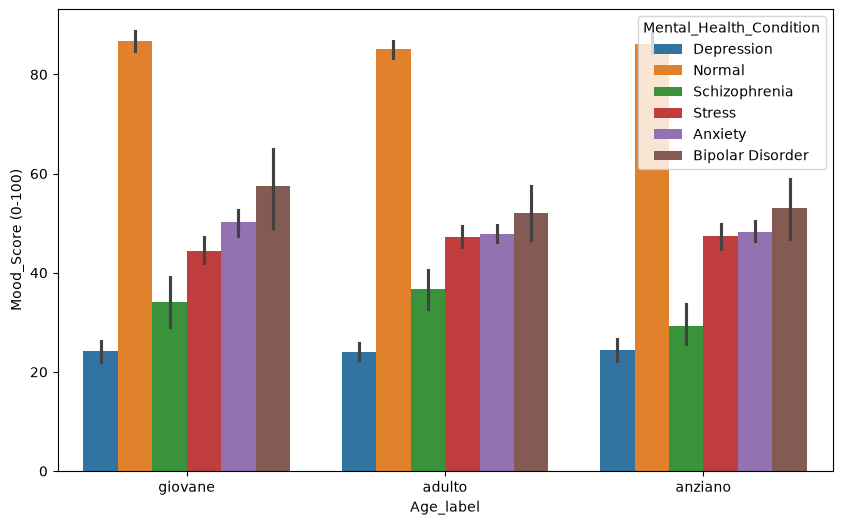

In [57]:
plt.figure(figsize=(10,6))
sns.barplot(x="Age_label", y="Mood_Score (0-100)", hue="Mental_Health_Condition", data=df)
plt.show()

creiamo le label

In [80]:
range1 = [-1, 20, 40, 60, 80,100]

df["Mood_label"] = pd.cut(
    df["Mood_Score (0-100)"],
    bins=range1,
    labels=["0-20","21-40", "41-60","61-80","81-100"]
)

df["Anxiety_label"] = pd.cut(
    df["Anxiety_Score (0-100)"],
    bins=range1,
    labels=["0-20","21-40", "41-60","61-80","81-100"]
)

df["Depression_label"] = pd.cut(
    df["Depression_Score (0-100)"],
    bins=range1,
    labels=["0-20","21-40", "41-60","61-80","81-100"]
)

df["Stress_label"] = pd.cut(
    df["Stress_Score (0-100)"],
    bins=range1,
    labels=["0-20","21-40", "41-60","61-80","81-100"]
)

df["Energy_label"] = pd.cut(
    df["Energy_Level (0-100)"],
    bins=range1,
    labels=["0-20","21-40", "41-60","61-80","81-100"]
)

df["Life_Satisfaction_label"] = pd.cut(
    df["Life_Satisfaction (0-100)"],
    bins=range1,
    labels=["0-20","21-40", "41-60","61-80","81-100"]
)



In [83]:
range2 = [0, 3, 7, 10]

df["Social_Interaction_label"] = pd.cut(
    df["Social_Interaction (1-10)"],
    bins=range2,
    labels=["low","medium", "high"]
)

df["Concentration_label"] = pd.cut(
    df["Concentration (1-10)"],
    bins=range2,
    labels=["low","medium", "high"]
)

df["Appetite_label"] = pd.cut(
    df["Appetite (1-10)"],
    bins=range2,
    labels=["low","medium", "high"]
)

In [84]:
df.to_csv("mhd2.csv", index=False, encoding="utf-8")

In [85]:
df

,Patient_ID,Age,Gender,Sleep_Hours_Per_Day,Work_Hours_Per_Week,Exercise_Frequency_Per_Week,Mood_Score (0-100),Anxiety_Score (0-100),Depression_Score (0-100),Stress_Score (0-100),...,Age_label,Mood_label,Anxiety_label,Depression_label,Stress_label,Energy_label,Life_Satisfaction_label,Social_Interaction_label,Concentration_label,Appetite_label
0,P0001,29,Female,5.0,48,1,38,56,77,70,...,giovane,21-40,41-60,61-80,61-80,21-40,21-40,medium,low,medium
1,P0002,24,Male,8.0,41,3,84,4,9,19,...,giovane,81-100,0-20,0-20,0-20,61-80,81-100,high,high,medium
2,P0003,46,Male,8.3,57,0,27,46,49,68,...,adulto,21-40,41-60,41-60,61-80,41-60,21-40,low,medium,medium
3,P0004,28,Male,4.1,38,4,53,56,26,80,...,giovane,41-60,41-60,21-40,61-80,21-40,21-40,medium,medium,medium
4,P0005,50,Male,5.2,15,3,33,94,35,82,...,adulto,21-40,81-100,21-40,81-100,41-60,21-40,medium,medium,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,P1196,23,Female,7.5,45,4,76,17,7,5,...,giovane,61-80,0-20,0-20,0-20,61-80,61-80,high,medium,high
1196,P1197,58,Male,7.4,13,4,88,5,10,19,...,anziano,81-100,0-20,0-20,0-20,81-100,61-80,high,high,medium
1197,P1198,63,Female,7.8,46,6,89,20,7,6,...,anziano,81-100,0-20,0-20,0-20,61-80,81-100,medium,medium,medium
1198,P1199,61,Female,4.7,7,0,28,78,50,67,...,anziano,21-40,61-80,41-60,61-80,21-40,21-40,low,low,medium
